In [72]:
from random_measurement import generate_povm_set_case_1,generate_povm_set_case_2
from blended_measurement import blended_measurement

import numpy as np
import matplotlib.pyplot as plt
from math import ceil

from tools import print_eigenvalue, show_probability_povm,construct_circuit_and_test,generate_binary_strings,construct_blended_circuit_and_test,resolve_blended_result,plot_sequential_blended_result


In [73]:
################### Initialization ######################################################

d = 2                             # Dimension of the initial state
m = 32                            # Number of POVM elements
case = 2                         # the case to test
state=np.array([[1,0]])           # initial state 
roh_0=np.array([[1,0],[0,0]])     # the density matrix of the initial state
num_shot=10000                    # the number of times to run the circuit
test_time=100                   # the number of times of impletemeting blended measuremnet

In [74]:

################### generate the povm measurement sets ##################################

if case==1:
    povm_set = generate_povm_set_case_1(d, m)
elif case==2:
    povm_set = generate_povm_set_case_2(d, m)

################### cauculate the probability of elements in povm set #################################################

# print_eigenvalue(povm_set)
povm_set_pro=show_probability_povm(povm_set,roh_0,False)

################# test the accepting probability of povm Mi (simulation)#################################################

state = state/np.linalg.norm(state) # normalize the state
result_povm=[]

for item in povm_set:
    povm=[]
    povm.append(item)
    inverse=np.eye(d)-item
    povm.append(inverse)    
    
    counts=construct_circuit_and_test(povm,state,num_shot)
    result_povm.append(counts['0'])

result_povm=[item/num_shot for item in result_povm]
# plt.plot(range(0,m),result_y)
# plt.show()


In [75]:
##################### cauculate the coefficients #################################

povm_set_pro=sorted(povm_set_pro,reverse=True)

if case==1:
    print("   Case 1")
    
    epsilon=1-povm_set_pro[0]
    print("1. epsilon is "+str(epsilon))
    
    beta=sum(povm_set_pro[1:])
    print("2. beta is "+str(beta))
    
    at_least_pro=((1-epsilon)**3)/(12*(1+beta))
    print("3. At least accepting probability is "+str(at_least_pro))

elif case==2:
    print("   Case 2")
    
    delta=sum(povm_set_pro[:])
    print("1. delta is "+str(delta))

   Case 2
1. delta is (0.2631840648078336+0j)


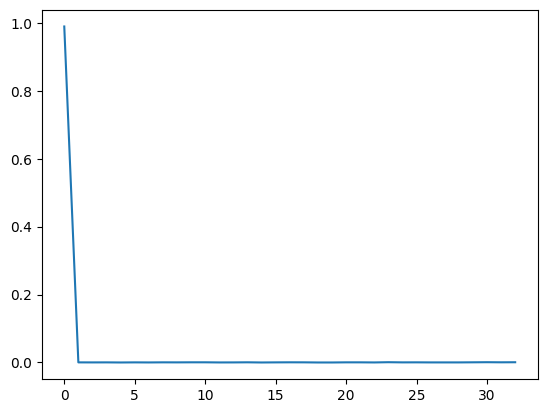

In [76]:
################## generate blended measurement sets #############################################

blended_set=blended_measurement(povm_set,d,m)
blended_set=[ item@item.T.conj() for item in blended_set]

################# test the accepting probability of blended measurement Ei (simulation) #################################################

counts=construct_circuit_and_test(blended_set,state,num_shot)

result_blended=[]

set_num=generate_binary_strings(int(ceil(np.log2(m)))+1)
set_num=np.array(list(sorted(set_num)))

cut=int((len(set_num)/2)+1)

for item in set_num[0:cut]:
    if item in counts.keys():
        result_blended.append(counts[item]/num_shot)
    else:
        result_blended.append(0)
        
plt.plot(range(0,m+1),result_blended)
plt.show()


In [77]:
############### Sequential Blend Measurement impletement(simulation) #########################
counts_set=[]
for i in range(test_time):
    counts=construct_blended_circuit_and_test(blended_set,state,1,m)
    counts_set.append(counts)


In [78]:
#################### Dealing with one sequential blended measurement result #########################

# count the appearing time of each outcome
# number_counts=resolve_blended_result(counts,m)
# labels, values = zip(*number_counts.items())

# Create the plot
# plot_sequential_blended_result(labels,values,m)

In [79]:
################## Check the theorem and the experiment result ######################################

if case == 2:
    accept_time=0
    for count in counts_set:
        number_counts=resolve_blended_result(count,m)
        # print(number_counts)
        labels, values = zip(*number_counts.items())
        if len(labels)>1:
            accept_time+=1
    print(accept_time)

21
